In [ ]:
url='https://raw.githubusercontent.com/drohanashM/Machine-Learning-MDTS4312-Assignments/refs/heads/main/GradientDescentUsingOOPs/Synthetic.csv'

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
df= pd.read_csv(url)

In [ ]:
df.head()

,Unnamed: 0,X,Y
0,0,37.454012,126.746701
1,1,95.071431,293.927975
2,2,73.199394,225.441700
3,3,59.865848,183.586508
4,4,15.601864,39.020372


In [ ]:
df=df.iloc[:,1:3]
X=df.iloc[:,0].values
y=df.iloc[:,1].values

In [ ]:
X=X.reshape(-1,1)
y=y.reshape(-1,1)



In [ ]:
m,features = X.shape
print(m)
print(features)

50
1


In [ ]:
# Standardization
x_mean = np.mean(X,axis=0)
x_std = np.std(X,axis=0)
X = (X-x_mean)/x_std

In [ ]:
# MINIBATCH

In [ ]:
#initialization
w=np.random.randn(features,1)
b=np.zeros((1,1))

In [ ]:
np.random.permutation(10)

array([3, 6, 1, 8, 0, 2, 5, 4, 7, 9])

In [ ]:
# Minibatch GD
batch_size=32
learning_rate=0.001
epoch=1
tol=0.005

losses=[]
prev_loss=float('inf')

while epoch < 1000:
  indices = np.random.permutation(m)
  x_shuffled = X[indices]
  y_shuffled = y[indices]

  for i in range(0,m,batch_size):
      X_batch=x_shuffled[i:i+batch_size]
      y_batch=y_shuffled[i:i+batch_size]

      #fp
      y_hat=np.dot(X_batch,w)+b
      error = y_hat-y_batch

      #gradients
      dw= ((1/len(X_batch)))*(np.dot(X_batch.T,error))
      db = ((1/len(X_batch)))*(np.sum(error))

      #update
      w=w-learning_rate*dw
      b=b-learning_rate*db

      #loss

  y_hat_full = np.dot(X,w)+b

  current_loss=np.mean((y_hat_full-y)**2)

  losses.append(current_loss)

  if abs(prev_loss - current_loss) < tol:
        break

  prev_loss = current_loss
  epoch += 1


final_loss =  losses[-1]
print(final_loss)


91.22985737234329


### Visualizing Loss and Regression Line

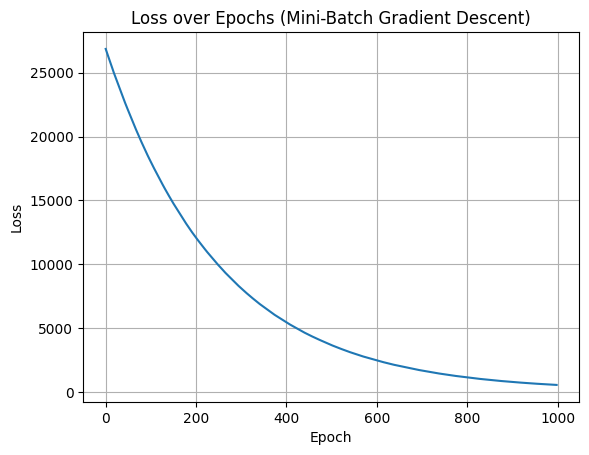

In [ ]:
plt.plot(range(len(losses)), losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss over Epochs (Mini-Batch Gradient Descent)')
plt.grid(True)
plt.show()

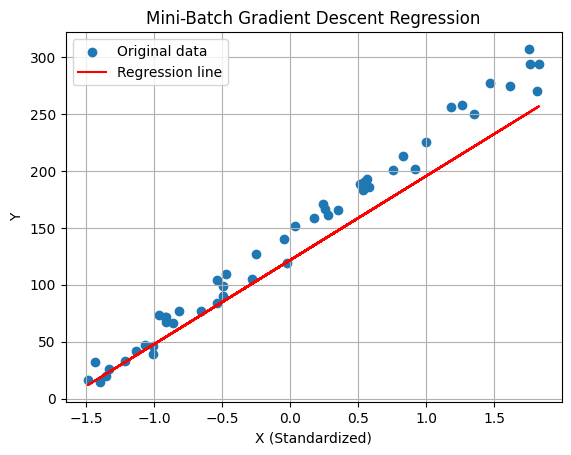

In [ ]:
# Plotting the regression line
plt.scatter(X, y, label='Original data')
plt.plot(X, y_hat_full, color='red', label='Regression line')
plt.xlabel('X (Standardized)')
plt.ylabel('Y')
plt.title('Mini-Batch Gradient Descent Regression')
plt.legend()
plt.grid(True)
plt.show()

### Stochastic Gradient Descent

In [ ]:
# Initialization for SGD
w_sgd = np.random.randn(features, 1)
b_sgd = np.zeros((1, 1))

learning_rate_sgd = 0.001 # Can be adjusted, often smaller than mini-batch
epoch_sgd = 1
tol_sgd = 0.005

losses_sgd = []
prev_loss_sgd = float('inf')

# Stochastic Gradient Descent
while epoch_sgd < 1000:
    indices = np.random.permutation(m)
    x_shuffled = X[indices]
    y_shuffled = y[indices]

    # In SGD, batch_size is 1
    for i in range(0, m, 1):
        X_batch = x_shuffled[i:i+1]
        y_batch = y_shuffled[i:i+1]

        # Forward pass
        y_hat_batch = np.dot(X_batch, w_sgd) + b_sgd
        error_batch = y_hat_batch - y_batch

        # Gradients
        dw_sgd = np.dot(X_batch.T, error_batch)
        db_sgd = np.sum(error_batch)

        # Update parameters
        w_sgd = w_sgd - learning_rate_sgd * dw_sgd
        b_sgd = b_sgd - learning_rate_sgd * db_sgd

    # Calculate loss after each epoch using the full dataset
    y_hat_full_sgd = np.dot(X, w_sgd) + b_sgd
    current_loss_sgd = np.mean((y_hat_full_sgd - y)**2)
    losses_sgd.append(current_loss_sgd)

    if abs(prev_loss_sgd - current_loss_sgd) < tol_sgd:
        break

    prev_loss_sgd = current_loss_sgd
    epoch_sgd += 1

print(f"SGD finished after {epoch_sgd} epochs. Final loss: {current_loss_sgd:.4f}")

SGD finished after 131 epochs. Final loss: 82.3632


### Visualizing SGD Loss and Regression Line

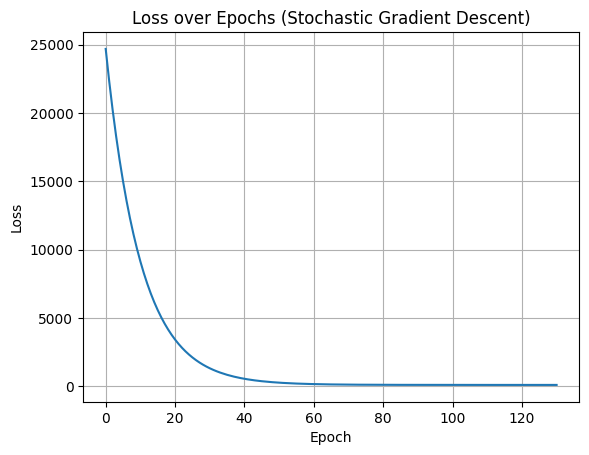

In [ ]:
plt.plot(range(len(losses_sgd)), losses_sgd)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss over Epochs (Stochastic Gradient Descent)')
plt.grid(True)
plt.show()

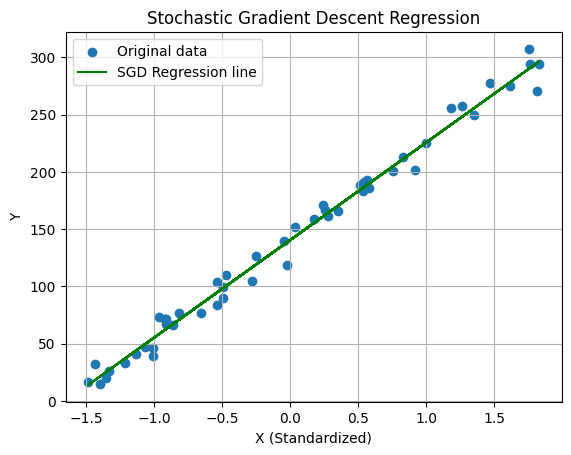

In [ ]:
# Plotting the regression line for SGD
plt.scatter(X, y, label='Original data')
plt.plot(X, y_hat_full_sgd, color='green', label='SGD Regression line')
plt.xlabel('X (Standardized)')
plt.ylabel('Y')
plt.title('Stochastic Gradient Descent Regression')
plt.legend()
plt.grid(True)
plt.show()

## Two Predictors and One Response

First, let's generate a synthetic dataset with two features (X1, X2) and one target (Y).

In [ ]:
# Generate synthetic data with 2 features
np.random.seed(42)
m_new = 100 # Number of samples
X1_new = 5 * np.random.rand(m_new, 1)
X2_new = 3 * np.random.rand(m_new, 1)
y_new = 4 + 2 * X1_new + 3 * X2_new + np.random.randn(m_new, 1) # Linear relationship with noise

X_new = np.hstack((X1_new, X2_new)) # Combine into a single feature matrix

# Standardize the new features
x_mean_new = np.mean(X_new, axis=0)
x_std_new = np.std(X_new, axis=0)
X_new_scaled = (X_new - x_mean_new) / x_std_new

print(f"New X_new_scaled shape: {X_new_scaled.shape}")
print(f"New y_new shape: {y_new.shape}")

New X_new_scaled shape: (100, 2)
New y_new shape: (100, 1)


Now, let's adapt the Mini-Batch Gradient Descent algorithm for this two-feature dataset.

In [ ]:
# Initialization for 2 features
features_new = X_new_scaled.shape[1]
w_new = np.random.randn(features_new, 1) # Weights for 2 features
b_new = np.zeros((1, 1))

batch_size_new = 20 # Using a new batch size for this example
learning_rate_new = 0.01 # Adjusted learning rate
epoch_new = 1
tol_new = 0.001

losses_new = []
prev_loss_new = float('inf')

m_new_samples = X_new_scaled.shape[0]

while epoch_new < 5000: # Increased epochs for potentially slower convergence
  indices_new = np.random.permutation(m_new_samples)
  x_shuffled_new = X_new_scaled[indices_new]
  y_shuffled_new = y_new[indices_new]

  for i in range(0, m_new_samples, batch_size_new):
      X_batch_new = x_shuffled_new[i:i+batch_size_new]
      y_batch_new = y_shuffled_new[i:i+batch_size_new]

      # Forward pass
      y_hat_batch_new = np.dot(X_batch_new, w_new) + b_new
      error_batch_new = y_hat_batch_new - y_batch_new

      # Gradients
      dw_new = ((1/len(X_batch_new)))*(np.dot(X_batch_new.T, error_batch_new))
      db_new = ((1/len(X_batch_new)))*(np.sum(error_batch_new))

      # Update parameters
      w_new = w_new - learning_rate_new * dw_new
      b_new = b_new - learning_rate_new * db_new

  # Calculate loss after each epoch using the full dataset
  y_hat_full_new = np.dot(X_new_scaled, w_new) + b_new
  current_loss_new = np.mean((y_hat_full_new - y_new)**2)
  losses_new.append(current_loss_new)

  if abs(prev_loss_new - current_loss_new) < tol_new:
        break

  prev_loss_new = current_loss_new
  epoch_new += 1

print(f"Mini-Batch GD (2 features) finished after {epoch_new} epochs. Final loss: {current_loss_new:.4f}")
print(f"Final weights (w_new): {w_new.flatten()}")
print(f"Final bias (b_new): {b_new.flatten()}")

Mini-Batch GD (2 features) finished after 99 epochs. Final loss: 0.9543
Final weights (w_new): [2.85154769 2.82141818]
Final bias (b_new): [13.19889678]


### Visualizing Loss and Regression Plane for 2 Features

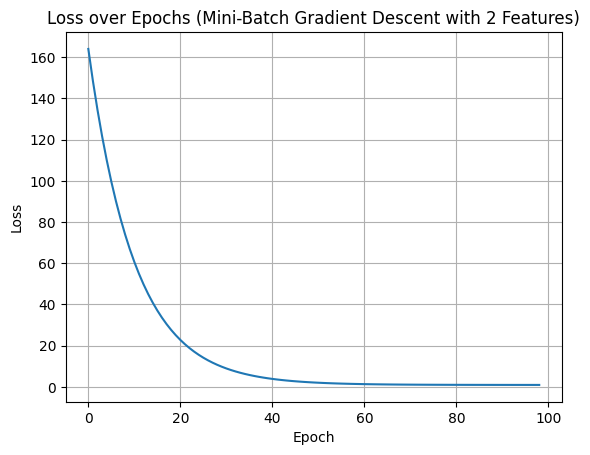

In [ ]:
plt.plot(range(len(losses_new)), losses_new)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss over Epochs (Mini-Batch Gradient Descent with 2 Features)')
plt.grid(True)
plt.show()